In [1]:
!python -m pip install opencv-python


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

Problema 1 - Ecualización local de histograma
----
La técnica de ecualización del histograma se puede extender para un análisis local, es decir,
se puede realizar una ecualización local del histograma. El procedimiento consiste en
definir una ventana cuadrada/rectangular (vecindario MxN) y mover el centro de la misma
de píxel en píxel. En cada ubicación, se calcula el histograma de los puntos dentro de la
ventana “deslizante” y se obtiene de esta manera, una transformación local de ecualización
del histograma. Esta transformación se utiliza finalmente para mapear el nivel de intensidad
del píxel centrado en la ventana bajo análisis, obteniendo así el valor del píxel
correspondiente a la imagen procesada. Luego, se desplaza la ventana un píxel hacia el
costado y se repite el procedimiento hasta recorrer toda la imagen.  

Esta técnica resulta útil cuando existen diferentes zonas de una imagen que poseen
detalles, los cuales se quiere resaltar, y los mismos poseen valores de intensidad muy
parecidos al valor del fondo local de la misma. En estos casos, una ecualización global del
histograma no daría buenos resultados, ya que se pierde la localidad del análisis al calcular
el histograma utilizando todos los píxeles de la imagen.  

Desarrolle una función para implementar la ecualización local del histograma, que reciba
como parámetros de entrada la imagen a procesar, y el tamaño de la ventana de
procesamiento (MxN). Utilice dicha función para analizar la imagen que se muestra en la
Figura 1 (archivo Imagen_con_objetos_ocultos.tiff) e informe cuáles son los detalles
escondidos en las diferentes zonas de la misma. Luego, desarrolle un análisis sobre la
influencia del tamaño de la ventana en los resultados obtenidos.

In [3]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["axes.grid"] = False

In [4]:
img_path = Path("Imagen_con_detalles_escondidos.tif")

img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"No se pudo cargar la imagen: {img_path}")

print(f"Dimensiones: {img.shape}")
print(f"Tipo de dato: {img.dtype}")
print(f"Rango de intensidades: [{img.min()}, {img.max()}]")

Dimensiones: (256, 256)
Tipo de dato: uint8
Rango de intensidades: [0, 228]


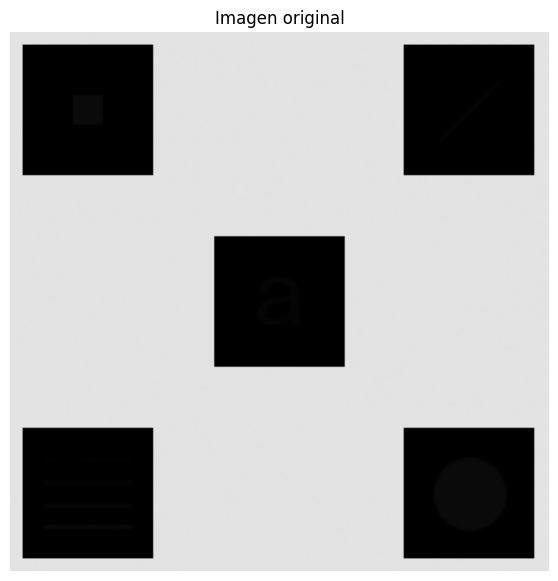

In [5]:
plt.figure(figsize=(7, 7))
plt.imshow(img, vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")
plt.show()

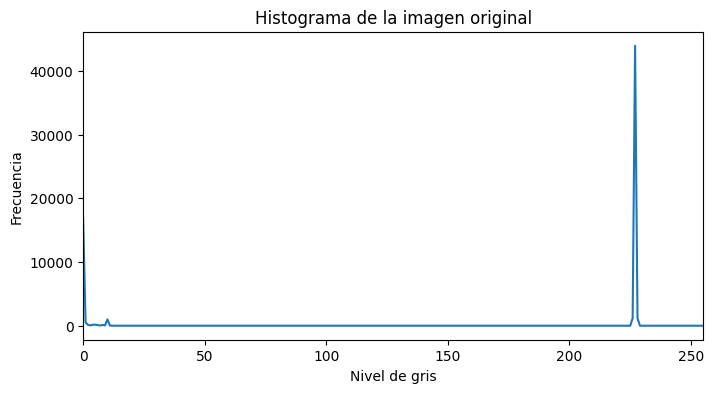

In [6]:
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.title("Histograma de la imagen original")
plt.xlabel("Nivel de gris")
plt.ylabel("Frecuencia")
plt.xlim(0, 255)
plt.show()

Se observa una gran distribución de pixeles concentrada en grises, se aplica una ecualización global para tratar distribuir mejor las intensidades y tratar de aprovechar mejor el rango disponible.

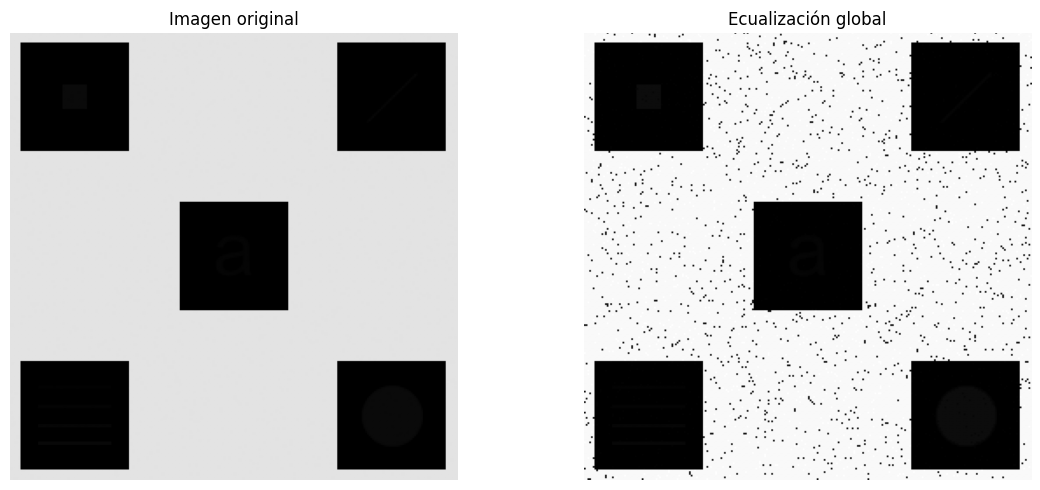

In [7]:
img_global_eq = cv2.equalizeHist(img)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(img, vmin=0, vmax=255)
ax[0].set_title("Imagen original")
ax[0].axis("off")

ax[1].imshow(img_global_eq, vmin=0, vmax=255)
ax[1].set_title("Ecualización global")
ax[1].axis("off")

plt.tight_layout()
plt.show()

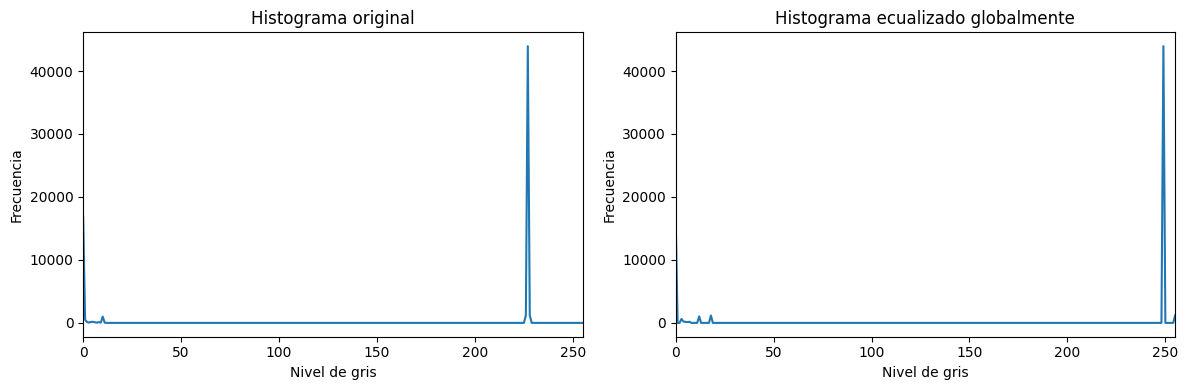

In [8]:
hist_global_eq, _ = np.histogram(img_global_eq.flatten(), 256, [0, 256])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist)
ax[0].set_title("Histograma original")
ax[0].set_xlabel("Nivel de gris")
ax[0].set_ylabel("Frecuencia")
ax[0].set_xlim(0, 255)

ax[1].plot(hist_global_eq)
ax[1].set_title("Histograma ecualizado globalmente")
ax[1].set_xlabel("Nivel de gris")
ax[1].set_ylabel("Frecuencia")
ax[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

A pesar de que la ecualización sigue habiendo una distribución muy marcada y todavía no se aprecian correctamente los detalles ocultos en la imagen, así que se define un método de ecualización local.

In [9]:
def local_hist_equalization(img, window_size=(31, 31)):
    """
    Aplica ecualización local de histograma a una imagen en escala de grises.
    """

    if img.ndim != 2:
        raise ValueError("La imagen debe estar en escala de grises.")
    
    if img.dtype != np.uint8:
        raise ValueError("La imagen debe ser de tipo uint8.")
    
    m, n = window_size
    
    if m <= 0 or n <= 0:
        raise ValueError("El tamaño de ventana debe ser positivo.")
    
    if m % 2 == 0 or n % 2 == 0:
        raise ValueError("El tamaño de ventana debe ser impar en ambas dimensiones.")
    
    pad_y = m // 2
    pad_x = n // 2

    img_pad = cv2.copyMakeBorder(
        img,
        top=pad_y,
        bottom=pad_y,
        left=pad_x,
        right=pad_x,
        borderType=cv2.BORDER_REPLICATE
    )

    out = np.zeros_like(img)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            window = img_pad[y:y + m, x:x + n]

            hist_local = np.bincount(window.ravel(), minlength=256)
            cdf = hist_local.cumsum()

            pixel_value = img[y, x]

            cdf_nonzero = cdf[hist_local > 0]

            if len(cdf_nonzero) == 0:
                out[y, x] = pixel_value
                continue

            cdf_min = cdf_nonzero[0]
            total = window.size

            if total == cdf_min:
                out[y, x] = pixel_value
            else:
                new_value = round((cdf[pixel_value] - cdf_min) * 255 / (total - cdf_min))
                out[y, x] = np.clip(new_value, 0, 255)

    return out.astype(np.uint8)

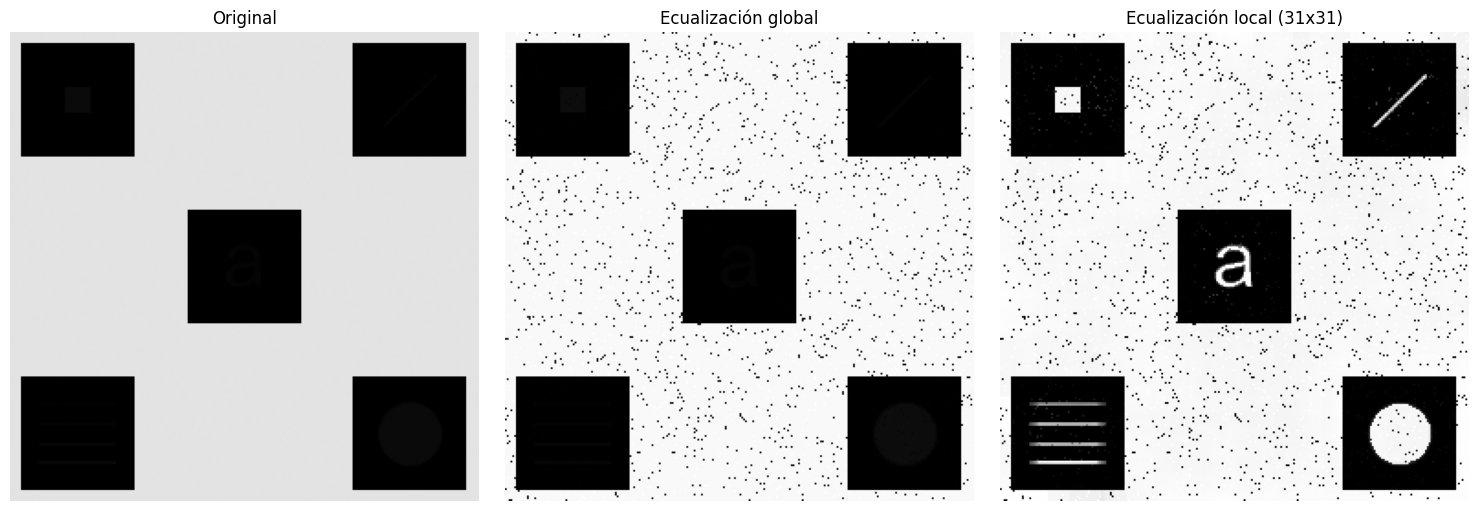

In [10]:
img_local_eq_31 = local_hist_equalization(img, window_size=(31, 31))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img, vmin=0, vmax=255)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(img_global_eq, vmin=0, vmax=255)
ax[1].set_title("Ecualización global")
ax[1].axis("off")

ax[2].imshow(img_local_eq_31, vmin=0, vmax=255)
ax[2].set_title("Ecualización local (31x31)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [11]:
window_sizes = [(15, 15), (31, 31), (63, 63)]

results = {}
for ws in window_sizes:
    results[ws] = local_hist_equalization(img, window_size=ws)

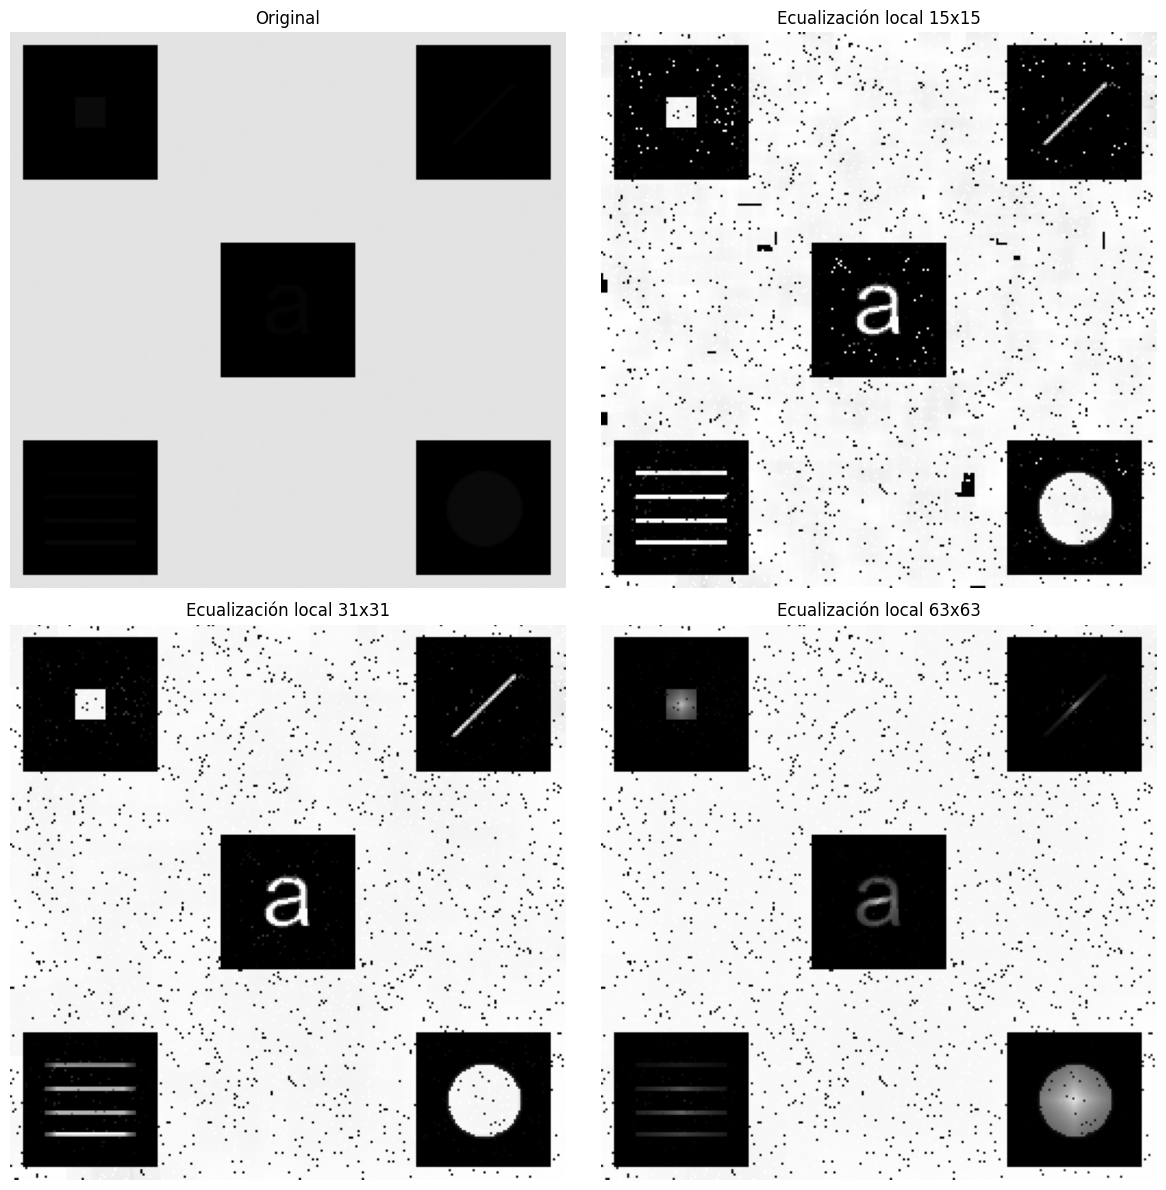

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))

ax[0, 0].imshow(img, vmin=0, vmax=255)
ax[0, 0].set_title("Original")
ax[0, 0].axis("off")

for i, ws in enumerate(window_sizes, start=1):
    r = (i // 2)
    c = (i % 2)
    ax[r, c].imshow(results[ws], vmin=0, vmax=255)
    ax[r, c].set_title(f"Ecualización local {ws[0]}x{ws[1]}")
    ax[r, c].axis("off")

plt.tight_layout()
plt.show()

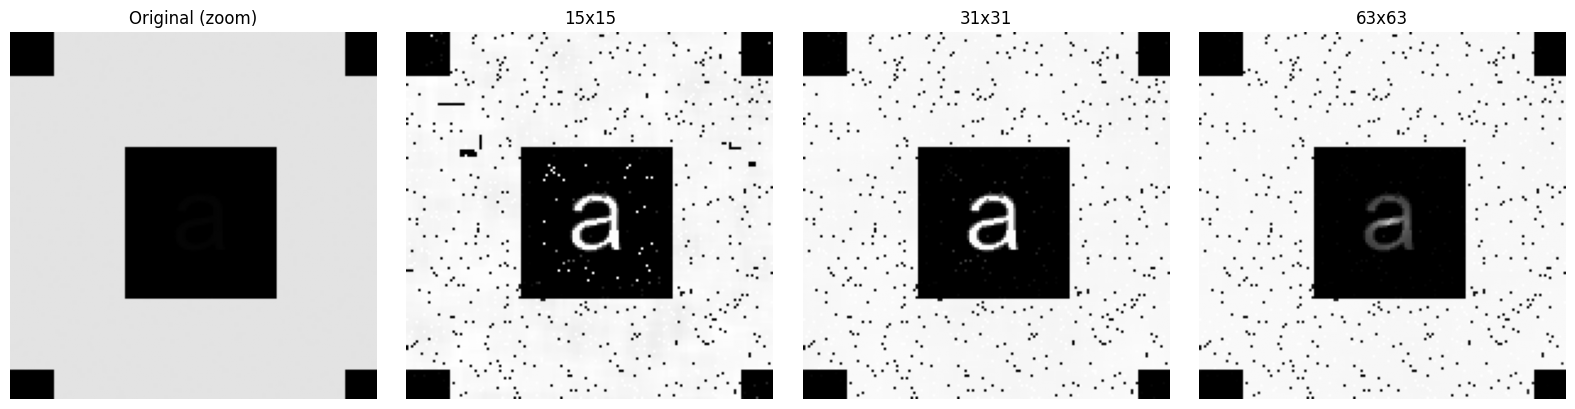

In [13]:
y1, y2 = 50, 200
x1, x2 = 50, 200

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(img[y1:y2, x1:x2], vmin=0, vmax=255)
ax[0].set_title("Original (zoom)")
ax[0].axis("off")

ax[1].imshow(results[(15, 15)][y1:y2, x1:x2], vmin=0, vmax=255)
ax[1].set_title("15x15")
ax[1].axis("off")

ax[2].imshow(results[(31, 31)][y1:y2, x1:x2], vmin=0, vmax=255)
ax[2].set_title("31x31")
ax[2].axis("off")

ax[3].imshow(results[(63, 63)][y1:y2, x1:x2], vmin=0, vmax=255)
ax[3].set_title("63x63")
ax[3].axis("off")

plt.tight_layout()
plt.show()

## Conclusión:

 Al hacer una ecualización global se logra un ajuste y ver los puntos dispersos por la imagen, pero no se consigue descubrir todos los detalles ocultos. Al aplicar una ecualización local con una ventana se logra un mejor ajuste, al variar el tamaño de la misma se permite variar la agresividad de la transformación. Al ser la ventana más pequeña se obtiene un resultado más "blanco/negro", con transiciones muy bruscas, mientras que al aumentar el tamaño se nota cómo las transiciones son más suaves, dando resultados que todavía conservan ciertos grises intermedios, pero, mientras al aumentar demasiado el valor de la ventana se termina obteniendo un resultado cada vez más cercano al de una ecualización global.